# Дослідження зарплат українських IT-спеціалістів

Дослідницький аналіз даних (EDA) опитування DOU.ua щодо зарплат українських IT-спеціалістів.

**Датасет:** 13 315 респондентів

**Період:** грудень 2022

**Джерело:** DOU.ua

**Мета:** дослідити закономірності зарплат залежно від тайтлу, досвіду, рівня англійської мови, статі та регіону.

## I. Підготовка середовища та завантаження даних

In [1]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

In [2]:
# Стилізація плотів
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [3]:
df = pd.read_csv('2022_dec_raw.csv', sep=';')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (13315, 28)


,Timestamp,Ви працюєте зараз в ІТ?,Де ви зараз живете?,В якій області ви зараз живете?,"Зарплата у $$$ за місяць, лише ставка після сплати податків",Ваша стать,Ваш вік,Яка у вас освіта?,Чи є у вас науковий ступінь?,Знання англійської мови,...,Ваша посада4,Ваша посада5,Ваша посада6,Ваша посада7,Чи використовуєте ви у своїй роботі мови програмування (одну чи декілька)?,Основна мова програмування,Вкажіть вашу основну спеціалізацію,В якій сфері працюєте?,Тип компанії,Загальний стаж роботи за спеціальністю
0,11.30.2022 10:26:37,"Так, працюю part-time",В Україні,Івано-Франківськ чи область,4000,Чоловік,29,"Вища (бакалавр, спеціаліст, магістр)",Немає,Intermediate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Blockchain,Стартап,8 років
1,11.30.2022 10:26:39,"Так, працюю full-time","За кордоном (переїхали через війну, але планую...",NaN,NaN,Чоловік,36,"Вища (бакалавр, спеціаліст, магістр)",Немає,Advanced,...,NaN,NaN,NaN,NaN,NaN,Ruby,Full Stack розробка,Public services / Government,Продуктова,3 роки
2,11.30.2022 10:26:58,"Так, працюю full-time",В Україні,Київ чи область,2500,Чоловік,34,"Вища (бакалавр, спеціаліст, магістр)",Немає,Elementary,...,NaN,NaN,NaN,NaN,NaN,C# / .NET,Full Stack розробка,"Adtech / Advertising, Security, Telecom",Продуктова,4 роки


In [4]:
df.columns

Index(['Timestamp', 'Ви працюєте зараз в ІТ?', 'Де ви зараз живете? ',
       'В якій області ви зараз живете?',
       'Зарплата у $$$ за місяць, лише ставка після сплати податків',
       'Ваша стать', 'Ваш вік', 'Яка у вас освіта?',
       'Чи є у вас науковий ступінь? ', 'Знання англійської мови',
       'Оберіть вашу посаду', 'Ваш тайтл', 'Ваша спеціалізація',
       'Вкажіть вашу спеціалізацію', 'Оберіть вашу спеціалізацію',
       'Ваша посада', 'Оберіть вашу посаду2', 'Ваша посада3', 'Ваша посада4',
       'Ваша посада5', 'Ваша посада6', 'Ваша посада7',
       'Чи використовуєте ви у своїй роботі мови програмування (одну чи декілька)?',
       'Основна мова програмування', 'Вкажіть вашу основну спеціалізацію',
       'В якій сфері працюєте?', 'Тип компанії',
       'Загальний стаж роботи за спеціальністю'],
      dtype='object')

In [5]:
# Змінення назв деяких колонок для зручності 
df = df.rename(columns={
    'Зарплата у $$$ за місяць, лише ставка після сплати податків': 'salary_usd',
    'Ваш тайтл': 'title',
    'Знання англійської мови': 'english_level',
    'Загальний стаж роботи за спеціальністю': 'experience',
    'В якій області ви зараз живете?': 'region',
    'Ваша стать': 'gender',
    'Ваш вік': 'age',
    'Основна мова програмування': 'programming_language',
    'Тип компанії': 'company_type',
    'В якій сфері працюєте?': 'industry',
    'Ваша спеціалізація': 'specialization'
})
df.head(3)

,Timestamp,Ви працюєте зараз в ІТ?,Де ви зараз живете?,region,salary_usd,gender,age,Яка у вас освіта?,Чи є у вас науковий ступінь?,english_level,...,Ваша посада4,Ваша посада5,Ваша посада6,Ваша посада7,Чи використовуєте ви у своїй роботі мови програмування (одну чи декілька)?,programming_language,Вкажіть вашу основну спеціалізацію,industry,company_type,experience
0,11.30.2022 10:26:37,"Так, працюю part-time",В Україні,Івано-Франківськ чи область,4000,Чоловік,29,"Вища (бакалавр, спеціаліст, магістр)",Немає,Intermediate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Blockchain,Стартап,8 років
1,11.30.2022 10:26:39,"Так, працюю full-time","За кордоном (переїхали через війну, але планую...",NaN,NaN,Чоловік,36,"Вища (бакалавр, спеціаліст, магістр)",Немає,Advanced,...,NaN,NaN,NaN,NaN,NaN,Ruby,Full Stack розробка,Public services / Government,Продуктова,3 роки
2,11.30.2022 10:26:58,"Так, працюю full-time",В Україні,Київ чи область,2500,Чоловік,34,"Вища (бакалавр, спеціаліст, магістр)",Немає,Elementary,...,NaN,NaN,NaN,NaN,NaN,C# / .NET,Full Stack розробка,"Adtech / Advertising, Security, Telecom",Продуктова,4 роки


## II. Очищення даних

In [6]:
# Огляд пропущених значень
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

Ваша посада7                                                                  13199
specialization                                                                13156
Ваша посада5                                                                  13027
Ваша посада                                                                   13010
Ваша посада6                                                                  12962
Ваша посада4                                                                  12830
Оберіть вашу спеціалізацію                                                    12829
Оберіть вашу посаду2                                                          12755
Ваша посада3                                                                  12494
Вкажіть вашу спеціалізацію                                                    10951
Чи використовуєте ви у своїй роботі мови програмування (одну чи декілька)?     8441
Вкажіть вашу основну спеціалізацію                                          

Так як це опитування, пропущенні значення в деяких колонках цілком очікувані, адже їхнє заповнення могло бути опціональне, тому було прийняте рішення не прибирати їх з датасету. Пропущені значення в колонці `region` були замінені на `"Unknown"`, щоб зберегти респондентів у датасеті та явно позначити відсутню інформацію про регіон.

In [7]:
df['region'] = df['region'].fillna('Unknown')
df['region'].isna().sum()

np.int64(0)

In [8]:
df.dtypes

Timestamp                                                                     object
Ви працюєте зараз в ІТ?                                                       object
Де ви зараз живете?                                                           object
region                                                                        object
salary_usd                                                                    object
gender                                                                        object
age                                                                           object
Яка у вас освіта?                                                             object
Чи є у вас науковий ступінь?                                                  object
english_level                                                                 object
Оберіть вашу посаду                                                           object
title                                                            

Колонки age та salary_usd були конвертовані у числовий формат.
Перед конвертацією значення зарплати були очищені від пробілів, а коми замінені на крапки.

In [9]:
df['age'] = (
    df['age'].astype(str).str.strip()
    .str.replace(',', '.', regex=False)
    .replace('nan', pd.NA)
    .astype(float)
)
df['age'].dtypes

dtype('float64')

In [10]:
df['salary_usd'] = (
    df['salary_usd']
    .astype(str)
    .str.strip()
    .str.replace(' ', '', regex=False)
    .str.replace(',', '.', regex=False)
    .replace(['nan', 'NaN', 'None', ''], pd.NA)
)

df['salary_usd'] = pd.to_numeric(df['salary_usd'], errors='coerce')

# Прибираю рядки без вказаної зарплати, щоб не впливали на метрики
df = df.dropna(subset=['salary_usd'])

df['salary_usd'].dtypes

dtype('float64')

Колонка Timestamp була перетворена у формат datetime.
Оскільки датасет містив декілька форматів дат, для обробки було використано кастомну функцію парсингу.

In [11]:
def parse_timestamp(x):
    if pd.isna(x):
        return pd.NaT
    x = str(x).strip()
    try:
        if len(x) == 19:
            return datetime.strptime(x, '%m.%d.%Y %H:%M:%S')
        else:
            return datetime.strptime(x, '%d.%m.%Y %H:%M')
    except:
        return pd.NaT

df['Timestamp'] = df['Timestamp'].apply(parse_timestamp).astype('datetime64[ns]')
df['Timestamp'].dtypes

dtype('<M8[ns]')

Для кращого розуміння структури категоріальних змінних було перевірено кількість унікальних значень та переглянуто найчастіші значення в кожній текстовій колонці.

In [12]:
df.select_dtypes(include='object').nunique()

Ви працюєте зараз в ІТ?                                                          5
Де ви зараз живете?                                                              2
region                                                                          24
gender                                                                           2
Яка у вас освіта?                                                                5
Чи є у вас науковий ступінь?                                                     3
english_level                                                                    5
Оберіть вашу посаду                                                             22
title                                                                           10
specialization                                                                   8
Вкажіть вашу спеціалізацію                                                       4
Оберіть вашу спеціалізацію                                                      21
Ваша

In [13]:
object_cols = df.select_dtypes(include='object').columns

for col in object_cols:
    print(f'\n==========')
    print(df[col].value_counts().head(10))


Ви працюєте зараз в ІТ?
Так, працюю full-time      12618
Ні, тимчасово не працюю      379
Так, працюю part-time        151
Так, я фрилансер             115
Інше                          25
Name: count, dtype: int64

Де ви зараз живете? 
В Україні                                                      11587
За кордоном (переїхали через війну, але планую повернутися)     1701
Name: count, dtype: int64

region
Київ чи область                4411
Львів чи область               2353
Unknown                        1750
Дніпро чи область               751
Івано-Франківськ чи область     478
Вінниця чи область              447
Одеса чи область                443
Харків чи область               355
Полтава чи область              252
Черкаси чи область              232
Name: count, dtype: int64

gender
Чоловік    10199
Жінка       3089
Name: count, dtype: int64

Яка у вас освіта?
Вища (бакалавр, спеціаліст, магістр)    10625
Дві вищі                                  998
Ще студент вишу          

Деякі категоріальні змінні мають природний порядок, наприклад рівень англійської мови, тайтл та досвід роботи.
Ці колонки були перетворені в ordered categorical type для коректного сортування у таблицях та візуалізаціях.

In [14]:
# Впорядковую категоріальні колонки 

ENGLISH_ORDER = [
    'Elementary',
    'Pre-Intermediate',
    'Intermediate',
    'Upper-Intermediate',
    'Advanced'
]

TITLE_ORDER = [
    'Intern/Trainee',
    'Junior',
    'Немає тайтлу',
    'Middle',
    'Senior',
    'Tech Lead',
    'Team Lead',
    'Architect',
    'Head',
    'Manager'
]

EXP_ORDER = [
    'Менше як 3 місяці',
    '3 місяці',
    'Пів року',
    '1 рік',
    '1,5 року',
    '2 роки',
    '3 роки',
    '4 роки',
    '5 років',
    '6 років',
    '7 років',
    '8 років',
    '9 років',
    '10 років',
    '11 років',
    '12 років',
    '13 років',
    '14 років',
    '15 і більше років'
]

df['english_level'] = pd.Categorical(
    df['english_level'],
    categories=ENGLISH_ORDER,
    ordered=True
)

df['title'] = pd.Categorical(
    df['title'],
    categories=TITLE_ORDER,
    ordered=True
)

df['experience'] = pd.Categorical(
    df['experience'],
    categories=EXP_ORDER,
    ordered=True
)

print('Cleaning complete ✓')

Cleaning complete ✓


## III. Аналіз даних

In [15]:
# Огляд даних
overview = {
    'Загальна кількість респондерів': len(df),
    'Унікальні посади': df['title'].nunique(),
    'Унікальні регіони': df['region'].nunique()
}

for key, value in overview.items():
    print(f'{key:<20}: {value:,}')

print('\nГендерний розподіл:')
print(df['gender'].value_counts())

Загальна кількість респондерів: 13,288
Унікальні посади    : 10
Унікальні регіони   : 24

Гендерний розподіл:
gender
Чоловік    10199
Жінка       3089
Name: count, dtype: int64


### Розподіл зарплат

На цьому етапі проаналізуємо загальний розподіл зарплат серед респондентів.

Оскільки зарплати можуть містити дуже високі значення, для гістограми було обмежено верхню межу до 10 000 USD. Це допомагає краще побачити основну частину розподілу.

Також порівняємо розподіл зарплат за статтю за допомогою boxplot.

In [16]:
df['salary_usd'].describe()

count    13288.000000
mean      3011.820647
std       2057.391947
min         50.000000
25%       1300.000000
50%       2600.000000
75%       4300.000000
max      19500.000000
Name: salary_usd, dtype: float64

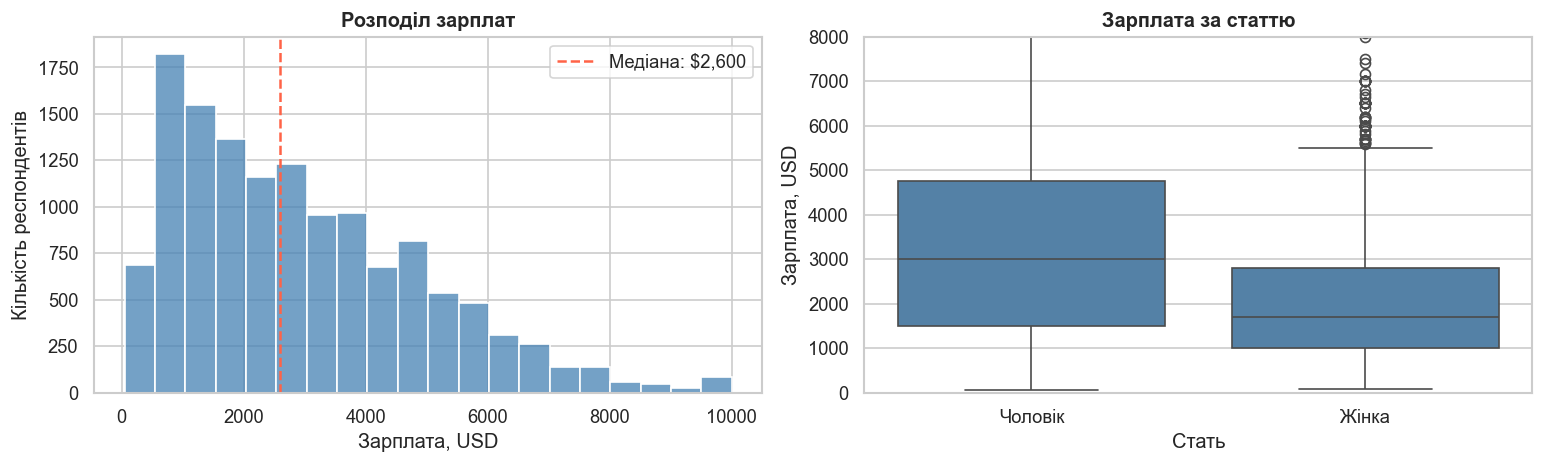

In [17]:
# Розподіл зарплати

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

salary_data = df['salary_usd'].dropna()

# Гістограма
sns.histplot(
    salary_data.clip(upper=10000),
    bins=20,
    ax=axes[0],
    color='steelblue'
)

median_salary = salary_data.median()

axes[0].axvline(
    median_salary,
    color='tomato',
    linestyle='--',
    label=f'Медіана: ${median_salary:,.0f}'
)

axes[0].set_title('Розподіл зарплат', fontweight='bold')
axes[0].set_xlabel('Зарплата, USD')
axes[0].set_ylabel('Кількість респондентів')
axes[0].legend()

# Boxplot за статтю
sns.boxplot(
    data=df,
    x='gender',
    y='salary_usd',
    ax=axes[1],
    color='steelblue'
)

axes[1].set_title('Зарплата за статтю', fontweight='bold')
axes[1].set_xlabel('Стать')
axes[1].set_ylabel('Зарплата, USD')
axes[1].set_ylim(0, 8000)

plt.tight_layout()
plt.savefig("viz_1_salary_distribution.png", dpi=150)
plt.show()

Розподіл зарплат має виражену правосторонню асиметрію: більшість респондентів отримує зарплати в нижньому та середньому діапазоні, тоді як невелика кількість високих зарплат формує довгий “хвіст” розподілу.

Медіанна зарплата становить приблизно 2600 USD на місяць, тоді як середня зарплата є вищою через вплив високих значень.

Порівняння за статтю показує, що в чоловіків медіанна зарплата та варіативність зарплат вищі. Водночас серед жінок також присутні високі зарплатні outliers.

### Найпоширеніші посади
Побудуємо графік найпоширеніших посад серед респондентів опитування.

Це дозволяє зрозуміти структуру вибірки та визначити, які напрямки найбільш представлені в українському IT.

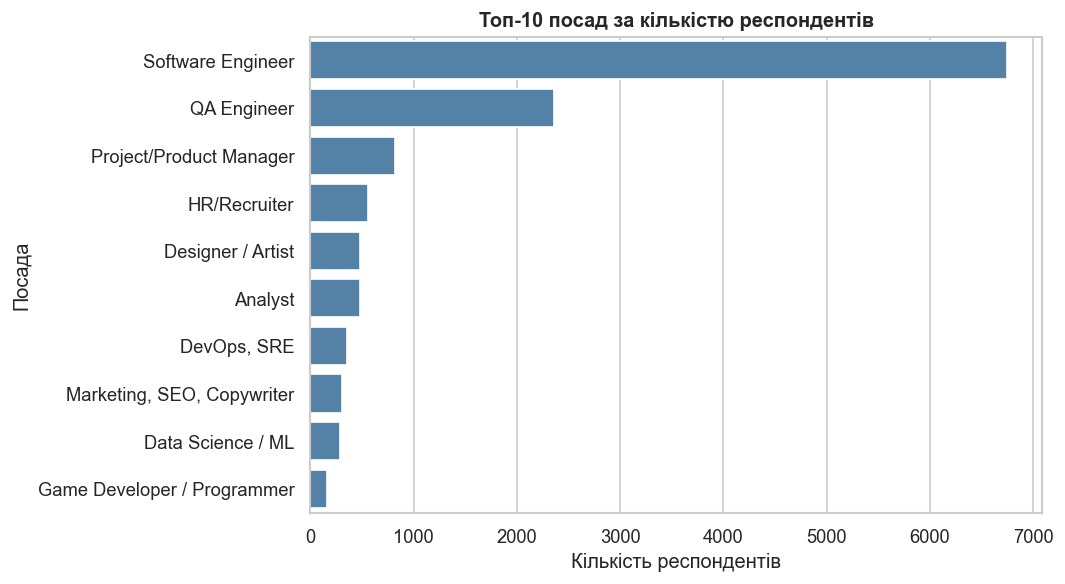

In [18]:
# Оптимізую назви посад
position_map = {
    'Software Engineer (Junior, Middle, Senior, Team/Tech Lead, Architect)': 'Software Engineer',
    'QA Engineer (Junior, Middle, Senior, Team/Tech Lead, Manager)': 'QA Engineer',
    'Project/Product/Program Manager, Product Owner, Scrum Master, Delivery Manager': 'Project/Product Manager',
    'Designer / Artist (Graphic, UX/UI, Game, Artist, Sound etc.)': 'Designer / Artist',
    'Analyst (Business, Data, System)': 'Analyst',
    'Data Science, Machine Learning, Big Data': 'Data Science / ML'
}

df['position_short'] = df['Оберіть вашу посаду'].replace(position_map)

# Графік топ-10 посад
top_positions = df['position_short'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    x=top_positions.values,
    y=top_positions.index,
    ax=ax,
    color='steelblue'
)

ax.set_title('Топ-10 посад за кількістю респондентів', fontweight='bold')
ax.set_xlabel('Кількість респондентів')
ax.set_ylabel('Посада')

plt.tight_layout()
plt.savefig("viz_2_top_10_positions.png", dpi=150)
plt.show()

Найбільшу частку респондентів складають Software Engineers — ця категорія суттєво переважає всі інші спеціальності у вибірці.

Другу за чисельністю групу становлять QA Engineers. Також у датасеті представлені менеджерські ролі, аналітики, дизайнери, спеціалісти Data Science та DevOps.

Розподіл посад у вибірці загалом відповідає структурі українського IT-ринку, де технічні спеціальності займають домінуючу частку.

### Зарплата за тайтлом та рівнем англійської

На цьому етапі порівняємо медіанну зарплату залежно від тайтлу спеціаліста та рівня англійської мови.

Для аналізу використовується саме медіана, оскільки зарплати мають викиди, а медіанне значення краще показує типовий рівень зарплати в групі.

In [19]:
df['title'] = df['title'].replace({
    'Немає тайтлу': 'No title'
})

# Зведена таблиця зарплатної медіани за тайтлом та рівнем англійської
pivot = pd.pivot_table(
    df,
    values='salary_usd',
    index='english_level',
    columns='title',
    aggfunc='median'
)
pivot

title,Intern/Trainee,Junior,No title,Middle,Senior,Tech Lead,Team Lead,Architect,Head,Manager
english_level,,,,,,,,,,
Elementary,500.0,600.0,550.0,1500.0,2500.0,5000.0,2100.0,NaN,1500.0,1120.0
Pre-Intermediate,400.0,800.0,934.0,1825.0,3500.0,4000.0,2850.0,2900.0,2400.0,1225.0
Intermediate,400.0,900.0,1300.0,2200.0,4100.0,5000.0,3800.0,5450.0,3500.0,2100.0
Upper-Intermediate,485.0,1000.0,1600.0,2500.0,4750.0,5650.0,4655.0,6400.0,4000.0,3600.0
Advanced,500.0,1000.0,2075.0,2500.0,4750.0,6000.0,5000.0,7000.0,5000.0,4000.0


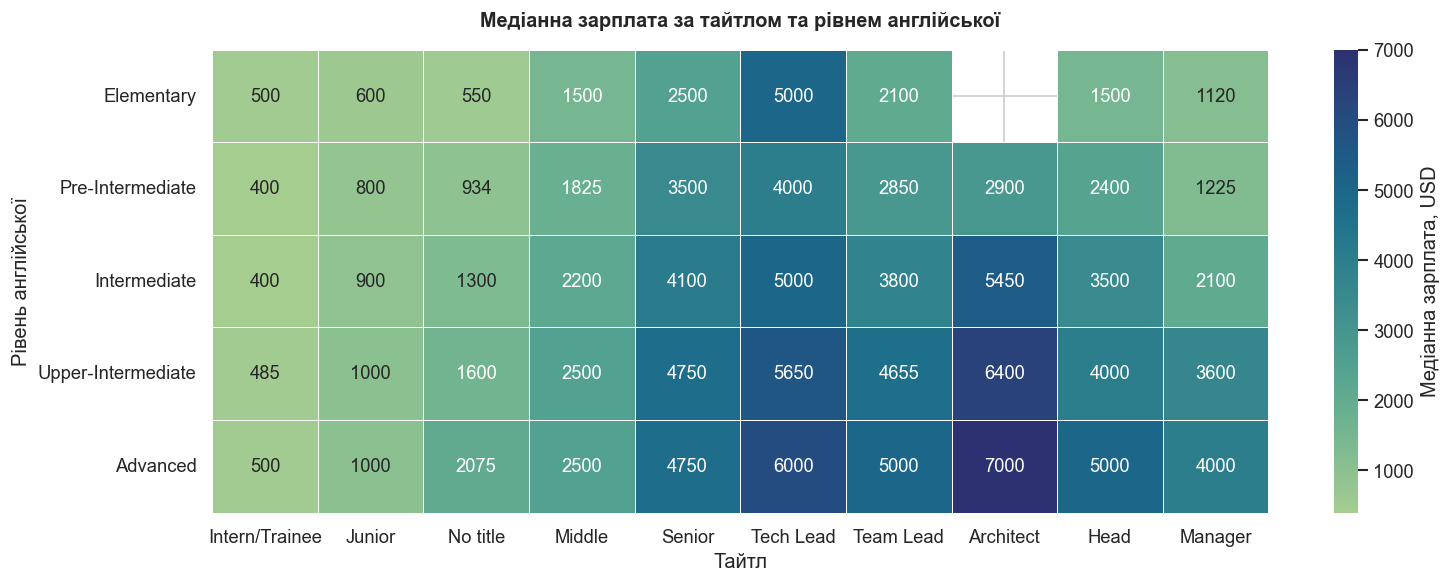

In [20]:
# Heatmap зарплатної медіани за тайтлом та рівнем англійської

fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='crest',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Медіанна зарплата, USD'}
)

ax.set_title('Медіанна зарплата за тайтлом та рівнем англійської', fontweight='bold', pad=14)
ax.set_xlabel('Тайтл')
ax.set_ylabel('Рівень англійської')

plt.tight_layout()
plt.savefig("viz_3_salary_heatmap.png", dpi=150)
plt.show()

Результати показують чіткий зв’язок між рівнем англійської мови та медіанною зарплатою.

Для більшості тайтлів зарплата зростає разом із покращенням рівня англійської. Найбільш помітний вплив англійської спостерігається серед senior-level спеціалістів, Team Lead, Architect та Manager позицій.

Найвищі медіанні зарплати мають Architect, Tech Lead та Team Lead ролі, особливо серед респондентів із рівнем англійської Upper-Intermediate та Advanced.

Для Junior-позицій вплив англійської також присутній, однак різниця в зарплатах є менш вираженою.

Tech Lead з Elementary ($5000) виглядає як аномалія або дуже специфічний випадок.

### Медіанна зарплата за рівнем англійської

Проаналізуємо, як змінюється медіанна зарплата залежно від рівня англійської мови.

Для порівняння використовується медіана, оскільки вона менш чутлива до викидів, ніж середнє значення.

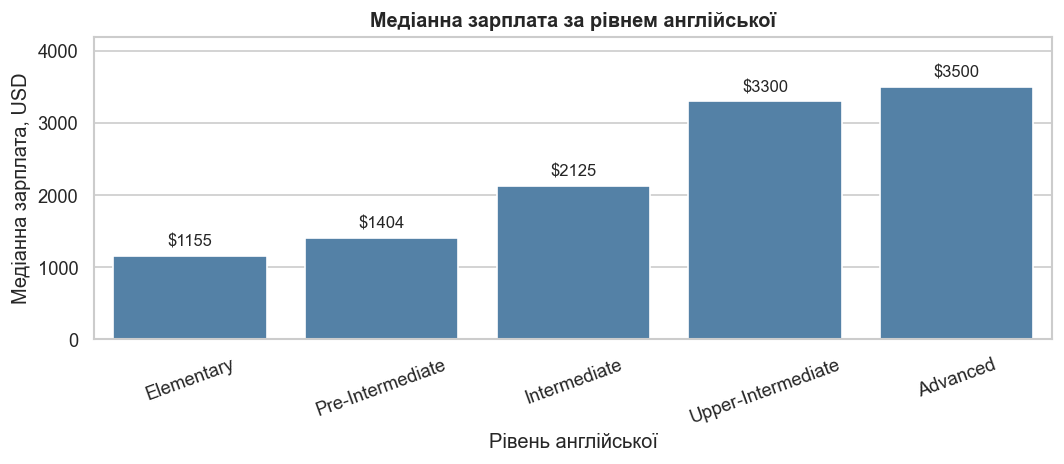

In [21]:
# Медіана зарплати за рівнем англійської
eng_salary = (
    df.groupby('english_level', observed=True)['salary_usd']
      .median()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))

sns.barplot(
    data=eng_salary,
    x='english_level',
    y='salary_usd',
    ax=ax,
    color='steelblue'
)

for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=4, fontsize=10)

ax.set_title('Медіанна зарплата за рівнем англійської', fontweight='bold')
ax.set_xlabel('Рівень англійської')
ax.set_ylabel('Медіанна зарплата, USD')
ax.set_ylim(0, eng_salary['salary_usd'].max() * 1.2)

plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("viz_4_salary_by_eng_level.png", dpi=150)
plt.show()

Медіанна зарплата зростає разом із рівнем англійської мови.

Найпомітніше зростання спостерігається між рівнями Intermediate та Upper-Intermediate. Це може свідчити про те, що вищий рівень англійської відкриває доступ до більш оплачуваних позицій, міжнародних команд або клієнтів.

### Зростання зарплати залежно від досвіду

Проаналізуємо, як змінюється медіанна зарплата залежно від кількості років досвіду.

Для аналізу використовується медіанна зарплата, оскільки вона краще відображає типовий рівень доходу та менш чутлива до викидів.

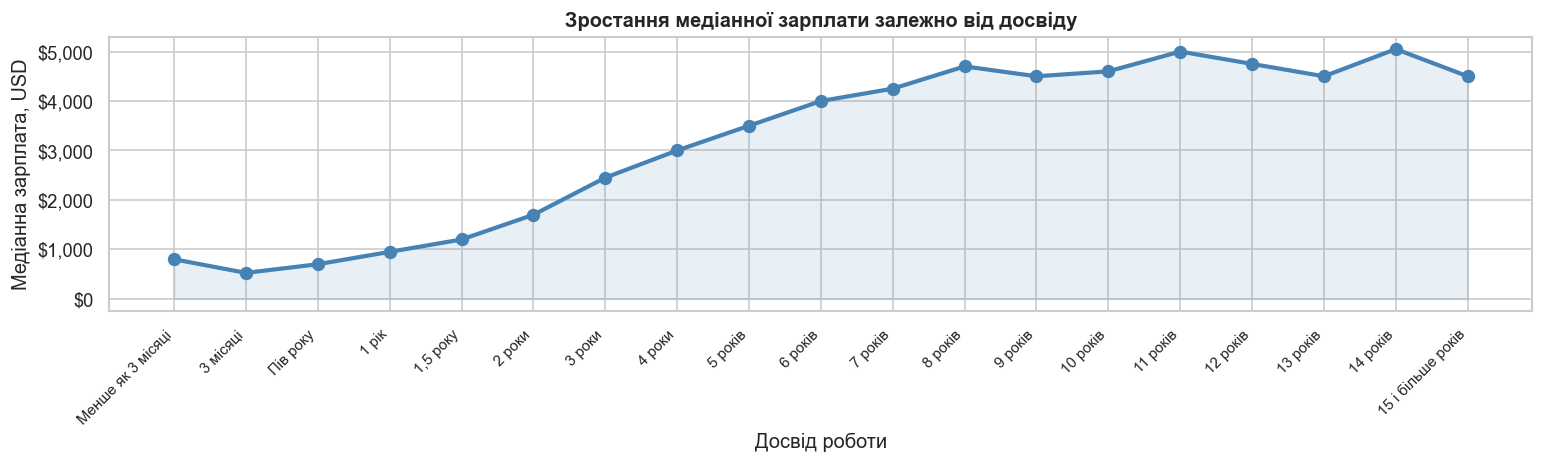

In [22]:
# Зростання зарплати з досвідом
exp_salary = (
    df.groupby('experience', observed=True)['salary_usd']
      .median()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 4))

# Лінійний графік
ax.plot(
    exp_salary['experience'].astype(str),
    exp_salary['salary_usd'],
    marker='o',
    color='steelblue',
    linewidth=2.5,
    markersize=7
)

# Площа під лінією
ax.fill_between(
    range(len(exp_salary)),
    exp_salary['salary_usd'],
    alpha=0.12,
    color='steelblue'
)

# Форматування осей
ax.set_xticks(range(len(exp_salary)))
ax.set_xticklabels(
    exp_salary['experience'].astype(str),
    rotation=45,
    ha='right',
    fontsize=9
)

ax.set_title('Зростання медіанної зарплати залежно від досвіду', fontweight='bold')
ax.set_xlabel('Досвід роботи')
ax.set_ylabel('Медіанна зарплата, USD')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.tight_layout()
plt.savefig("viz_5_salary_by_experience.png", dpi=150)
plt.show()

Медіанна зарплата має чітку позитивну залежність від досвіду роботи.

Найшвидше зростання зарплати спостерігається в перші 5–6 років кар’єри. За цей період медіанна зарплата зростає приблизно з 500–800 USD до 3500–4000 USD.

Після 7–8 років досвіду темп зростання помітно сповільнюється, а зарплата переходить у фазу відносної стабілізації на рівні близько 4500–5000 USD.

Також помітно, що після 10 років досвіду коливання зарплат стають менш передбачуваними. Це може свідчити про те, що на senior-рівні більший вплив на дохід мають спеціалізація, управлінські ролі, доменна експертиза та тип компанії, а не лише кількість років досвіду.

### Регіональний аналіз

Проаналізуємо, як відрізняється розподіл зарплат між регіонами України.

Для візуалізації обрано топ-7 регіонів за кількістю респондентів, щоб порівняння було більш репрезентативним.  
Регіони на графіку відсортовані за медіанною зарплатою.

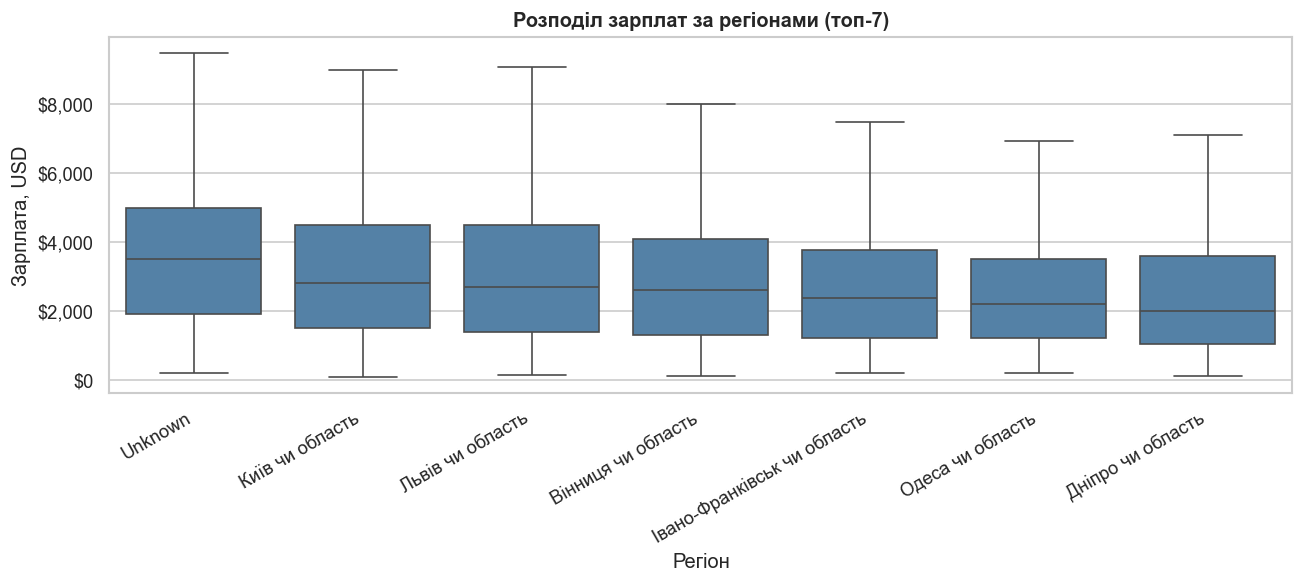

In [23]:
# --- Regional salary analysis ---

top_regions = df['region'].value_counts().head(7).index
df_reg = df[df['region'].isin(top_regions)].copy()

# Sort regions by median salary
reg_order = (
    df_reg.groupby('region')['salary_usd']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
    data=df_reg,
    x='region',
    y='salary_usd',
    order=reg_order,
    color='steelblue',
    showfliers=False,
    ax=ax
)

ax.set_title('Розподіл зарплат за регіонами (топ-7)', fontweight='bold')
ax.set_xlabel('Регіон')
ax.set_ylabel('Зарплата, USD')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.xticks(rotation=30, ha='right')
plt.savefig("viz_6_salary_by_region.png", dpi=150)
plt.tight_layout()
plt.show()

Розподіл зарплат між регіонами є відносно схожим, однак певні відмінності все ж помітні.

Найвищу медіанну зарплату серед топ-7 регіонів має Київ та область, що відповідає ролі Києва як основного IT-хабу України.

Львів та Вінниця також демонструють високі медіанні зарплати та широкий діапазон доходів, що може свідчити про присутність великої кількості senior-спеціалістів і міжнародних компаній.

У більшості регіонів медіанна зарплата знаходиться в межах 2000–3000 USD, а розподіл зарплат має значну варіативність.

### Гендерний розрив у оплаті праці

Проаналізуємо різницю в медіанних зарплатах між чоловіками та жінками.

In [24]:
# Аналіз гендерного розриву

gender_median = (
    df.groupby('gender')['salary_usd']
    .median()
)

gap_pct = (
    (gender_median['Чоловік'] - gender_median['Жінка'])
    / gender_median['Чоловік']
    * 100
)

print(
    f"Медіанна зарплата — "
    f"Чоловіки: ${gender_median['Чоловік']:,.0f} | "
    f"Жінки: ${gender_median['Жінка']:,.0f}"
)

print(f"Гендерний розрив складає: {gap_pct:.1f}%")

Медіанна зарплата — Чоловіки: $3,000 | Жінки: $1,690
Гендерний розрив складає: 43.7%


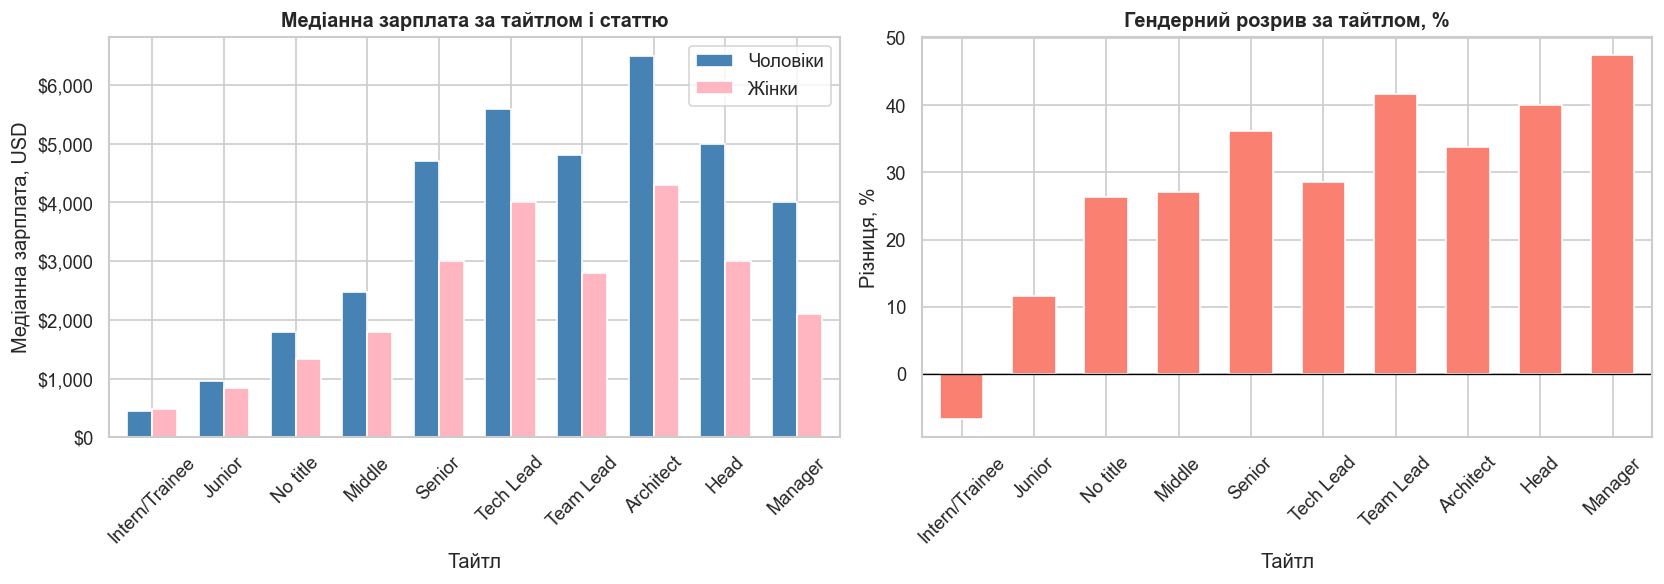

In [25]:
# Групую дані за тайтлом та статтю

gap_by_title = (
    df.groupby(['title', 'gender'], observed=True)['salary_usd']
      .median()
      .unstack()
)

gap_by_title['Gap, %'] = (
    (gap_by_title['Чоловік'] - gap_by_title['Жінка'])
    / gap_by_title['Чоловік']
    * 100
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Медіана зарплати за тайтлом та статтю
gap_by_title[['Чоловік', 'Жінка']].plot.bar(
    ax=axes[0],
    color=['steelblue', 'lightpink'],
    width=0.7
)

axes[0].set_title('Медіанна зарплата за тайтлом і статтю', fontweight='bold')
axes[0].set_xlabel('Тайтл')
axes[0].set_ylabel('Медіанна зарплата, USD')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
axes[0].legend(['Чоловіки', 'Жінки'])

# Гендерний розрив за тайтлом
gap_by_title['Gap, %'].dropna().plot.bar(
    ax=axes[1],
    color='salmon',
    width=0.6
)

axes[1].set_title('Гендерний розрив за тайтлом, %', fontweight='bold')
axes[1].set_xlabel('Тайтл')
axes[1].set_ylabel('Різниця, %')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig("viz_7_gender_gap.png", dpi=150)
plt.show()

Для більш детального аналізу побудуємо таблицю з медіанною зарплатою чоловіків і жінок у межах кожного тайтлу.

Колонка `Gap, %` показує відсоткову різницю між медіанною зарплатою чоловіків і жінок. Чим темніше забарвлення, тим більший розрив.

In [26]:
gap_by_title.style \
    .background_gradient(subset=['Gap, %'], cmap='Reds') \
    .format({
        'Чоловік': '${:.0f}',
        'Жінка': '${:.0f}',
        'Gap, %': '{:.1f}%'
    }, na_rep='-') \
    .set_caption('Gender pay gap за тайтлом')

gender,Жінка,Чоловік,"Gap, %"
title,,,
Intern/Trainee,$480,$450,-6.7%
Junior,$840,$950,11.6%
No title,$1326,$1800,26.3%
Middle,$1800,$2470,27.1%
Senior,$3000,$4700,36.2%
Tech Lead,$4000,$5600,28.6%
Team Lead,$2800,$4800,41.7%
Architect,$4300,$6500,33.8%
Head,$3000,$5000,40.0%


У більшості тайтлів медіанна зарплата чоловіків є вищою за медіанну зарплату жінок.

Найменша різниця спостерігається на Junior та Intern/Trainee позиціях, де зарплати є відносно близькими.

Із зростанням seniority гендерний розрив поступово збільшується. Найбільший гендерний розрив спостерігається для Manager, Head, Team Lead та Architect ролей.

Це може свідчити про те, що на senior та management-рівнях жінки рідше займають найбільш високооплачувані позиції або мають меншу представленість у високодохідних компаніях та спеціалізаціях.


## IV Key Insights

- Медіанна зарплата в датасеті становить приблизно 2600 USD на місяць.
- Salary distribution є right-skewed через наявність високих зарплатних outliers.
- Найвищі зарплати мають Architect, Tech Lead та Head позиції.
- Найбільше зростання зарплати відбувається в перші 5–6 років кар’єри.
- Рівень англійської суттєво впливає на рівень доходу.
- Київ та область мають одну з найвищих медіанних зарплат серед регіонів.
- Software Engineer є найбільш представленою посадою у вибірці.
- У більшості тайтлів спостерігається гендерний розрив на користь чоловіків.

## V Загальні висновки

У межах цього дослідницького аналізу було проаналізовано зарплати понад 13 тисяч українських IT-спеціалістів за даними DOU.ua за грудень 2022 року.

Аналіз показав, що рівень зарплати в IT суттєво залежить від досвіду роботи, тайтлу, рівня англійської мови та регіону проживання.

Розподіл зарплат має виражену правосторонню асиметрію: більшість респондентів отримує зарплати в середньому діапазоні, тоді як невелика кількість високих зарплат формує довгий “хвіст” розподілу.

Найвищі медіанні зарплати спостерігаються серед Architect, Tech Lead, Team Lead та Head ролей. Водночас Junior та Intern/Trainee позиції мають значно нижчий рівень доходу.

Рівень англійської мови демонструє сильну позитивну кореляцію із зарплатою. Найбільший вплив англійська має для senior-level та management-позицій.

Зарплата також суттєво зростає разом із досвідом роботи, особливо протягом перших 5–6 років кар’єри. Після 8–10 років досвіду темп росту стає менш вираженим.

Регіональний аналіз показав, що Київ та область залишаються одним із найбільш високооплачуваних IT-регіонів України, хоча різниця між великими IT-хабами є відносно помірною.

Також було виявлено гендерний розрив: у більшості тайтлів медіанна зарплата чоловіків є вищою за зарплату жінок, причому розрив збільшується на senior та management-рівнях.